# 09 — Paper Figures

Publication-quality figures for the manuscript.

| Fig | Content | Type |
|-----|---------|------|
| 1 | Calibration scatter (obs vs predicted) | scatter + regression |
| 2 | Global emission ratio map | cartopy point map |
| 3 | Cumulative concentration curves | line plot |
| 4 | Bootstrap uncertainty distributions | histogram |
| 5 | Top-20 ranking comparison | horizontal bar |

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from scipy.spatial import cKDTree
from numpy.linalg import lstsq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

DATA_PROC = Path('../data/processed')
DATA_RAW = Path('../data/raw')
FIG = Path('../results/figures')
FIG.mkdir(parents=True, exist_ok=True)

MEEKER_BLUE = '#2166ac'
UPDATED_RED = '#b2182b'
GRAY = '#888888'

## Load data & recompute model

In [2]:
fm = pd.read_csv(DATA_PROC / 'feature_matrix_v1.csv')
cal = pd.read_csv(DATA_PROC / 'recalibrated_emissions_v1.csv')
obs = pd.read_csv(DATA_PROC / 'observed_flux_matched_S3.csv')
waw = pd.read_csv(DATA_RAW / 'worldbank_waste' / 'what_a_waste_3.0_processed.csv')
waw = waw[waw['iso3'] != 'iso3c']
ranking = pd.read_csv(DATA_PROC / 'final_ranking_v2.csv')

df = fm.copy()
df['meijer_ton_yr'] = cal['meijer_ton_yr']

# --- Data quality fixes ---
df.loc[df['ENDORHEIC'] == 1, 'meijer_ton_yr'] = 0

high_income = ['USA', 'GBR', 'ITA', 'CAN', 'AUS', 'FRA', 'DEU', 'ESP',
               'NLD', 'BEL', 'AUT', 'CHE', 'SWE', 'NOR', 'DNK', 'FIN',
               'IRL', 'NZL', 'PRT', 'GRC', 'CZE', 'KOR', 'SGP',
               'TWN', 'ISR', 'SAU', 'UAE', 'QAT', 'KWT', 'BHR', 'OMN']
hi_mask = (df['mismanaged_pct'] == 50.0) & df['country_iso'].isin(high_income)
correction = np.ones(len(df))
correction[hi_mask.values] = 3.0 / 50.0
df['meijer_ton_yr'] = df['meijer_ton_yr'] * correction

no_country = df['country_iso'].isna()
gdf_unmatched = gpd.GeoDataFrame(
    df[no_country],
    geometry=gpd.points_from_xy(df.loc[no_country, 'lon'], df.loc[no_country, 'lat']),
    crs='EPSG:4326'
)
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')
gdf_unmatched = gdf_unmatched.to_crs(epsg=3857)
world_proj = world.to_crs(epsg=3857)
matched = gpd.sjoin_nearest(gdf_unmatched, world_proj[['ISO_A3_EH', 'geometry']],
                            how='left', max_distance=50000)
matched = matched[~matched.index.duplicated(keep='first')]
waw_dict = dict(zip(waw['iso3'], waw['plastic_pct']))
for idx_val in matched.index:
    iso = matched.loc[idx_val, 'ISO_A3_EH']
    if pd.notna(iso):
        df.loc[idx_val, 'country_iso'] = iso
        if iso in waw_dict:
            df.loc[idx_val, 'plastic_pct'] = waw_dict[iso]

# --- Plastic fraction correction ---
df['plastic_ratio'] = df['plastic_pct'] / 12.0
df['E_corrected'] = df['meijer_ton_yr'] * df['plastic_ratio']

# --- Nightlight deviation ---
country_nl_mean = df.groupby('country_iso')['nightlight_intensity'].transform('mean')
df['nl_deviation'] = (df['nightlight_intensity'] - country_nl_mean).fillna(0)

# --- Calibrate ---
obs_coords = np.column_stack([obs['lon'].values, obs['lat'].values])
df_coords = np.column_stack([df['lon'].values, df['lat'].values])
tree = cKDTree(df_coords)
dist, idx = tree.query(obs_coords)

obs_corrected = df.iloc[idx]['E_corrected'].values
obs_nl_dev = df.iloc[idx]['nl_deviation'].values
valid = obs_corrected > 0

log_obs = np.log10(obs['obs_annual'].values[valid])
log_pred = np.log10(obs_corrected[valid])
nl_dev_obs = obs_nl_dev[valid]

A = np.column_stack([np.ones(len(log_obs)), log_pred, nl_dev_obs])
coefs, _, _, _ = lstsq(A, log_obs, rcond=None)

mask = df['E_corrected'].values > 0
E_final = np.zeros(len(df))
log_E = np.log10(df.loc[mask, 'E_corrected'].values)
nl_dev = df.loc[mask, 'nl_deviation'].values
E_final[mask] = 10 ** (coefs[0] + coefs[1] * log_E + coefs[2] * nl_dev)
df['E_final'] = E_final

# Meijer original (before fixes)
E_meijer_orig = cal['meijer_ton_yr'].values

print(f'Rivers: {len(df):,}')
print(f'Meijer total: {E_meijer_orig.sum():,.0f} ton/yr')
print(f'Updated total: {E_final.sum():,.0f} ton/yr')

Rivers: 31,819
Meijer total: 1,005,984 ton/yr
Updated total: 889,196 ton/yr


## Figure 1: Calibration scatter

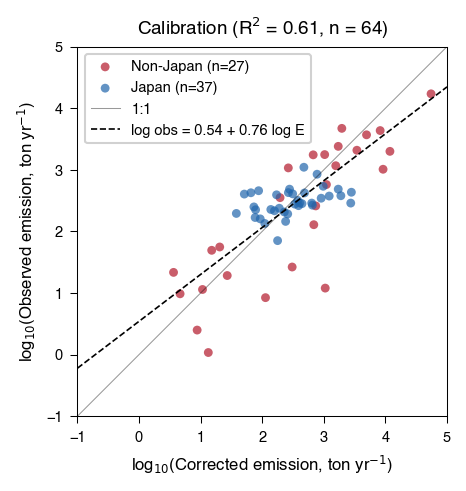

In [3]:
log_fitted = A @ coefs
r2 = 1 - np.sum((log_obs - log_fitted)**2) / np.sum((log_obs - log_obs.mean())**2)

# Color by country group
obs_country = obs['country'].values[valid]
is_japan = obs_country == 'JPN'

fig, ax = plt.subplots(figsize=(3.5, 3.2))

ax.scatter(log_pred[~is_japan], log_obs[~is_japan],
           s=18, alpha=0.7, edgecolors='none', c=UPDATED_RED, label=f'Non-Japan (n={(~is_japan).sum()})')
ax.scatter(log_pred[is_japan], log_obs[is_japan],
           s=18, alpha=0.7, edgecolors='none', c=MEEKER_BLUE, label=f'Japan (n={is_japan.sum()})')

# 1:1 line
lims = [-1, 5]
ax.plot(lims, lims, 'k-', lw=0.5, alpha=0.4, label='1:1')

# Regression line (marginalized over nightlight)
x_line = np.linspace(-1, 5, 100)
y_line = coefs[0] + coefs[1] * x_line
ax.plot(x_line, y_line, '--', color='k', lw=0.8,
        label=f'log obs = {coefs[0]:.2f} + {coefs[1]:.2f} log E')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('log$_{10}$(Corrected emission, ton yr$^{-1}$)')
ax.set_ylabel('log$_{10}$(Observed emission, ton yr$^{-1}$)')
ax.set_title(f'Calibration (R$^2$ = {r2:.2f}, n = {valid.sum()})')
ax.legend(loc='upper left', frameon=True, framealpha=0.9)
ax.set_aspect('equal')

fig.savefig(FIG / 'fig1_calibration_scatter.png')
fig.savefig(FIG / 'fig1_calibration_scatter.pdf')
plt.show()

## Figure 2: Global emission ratio map

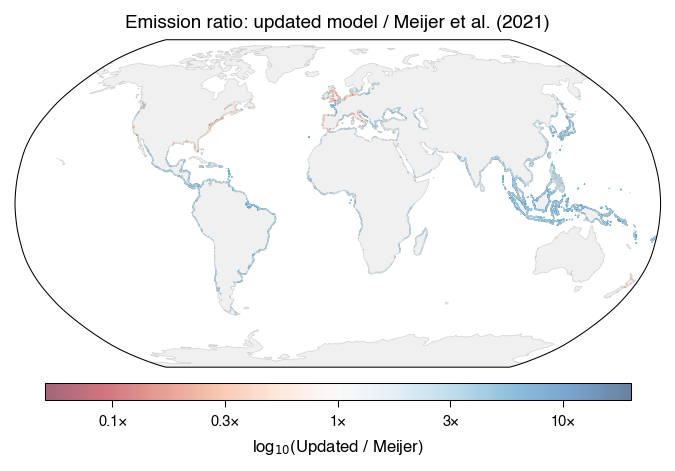

In [4]:
ratio = np.where(E_meijer_orig > 0, E_final / E_meijer_orig, np.nan)
log_ratio = np.log10(np.clip(ratio, 0.05, 5))

fig = plt.figure(figsize=(7.2, 3.5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#ffffff', edgecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.3, color='#cccccc')
ax.set_global()

valid_map = np.isfinite(log_ratio) & (E_final > 0)
sc = ax.scatter(
    df.loc[valid_map, 'lon'].values,
    df.loc[valid_map, 'lat'].values,
    c=log_ratio[valid_map],
    s=0.4, alpha=0.6, edgecolors='none',
    cmap='RdBu', vmin=-1.3, vmax=1.3,
    transform=ccrs.PlateCarree()
)

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04,
                     aspect=35, shrink=0.7)
cbar.set_label('log$_{10}$(Updated / Meijer)')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['0.1×', '0.3×', '1×', '3×', '10×'])

ax.set_title('Emission ratio: updated model / Meijer et al. (2021)')

fig.savefig(FIG / 'fig2_global_ratio_map.png')
fig.savefig(FIG / 'fig2_global_ratio_map.pdf')
plt.show()

## Figure 3: Cumulative concentration curves

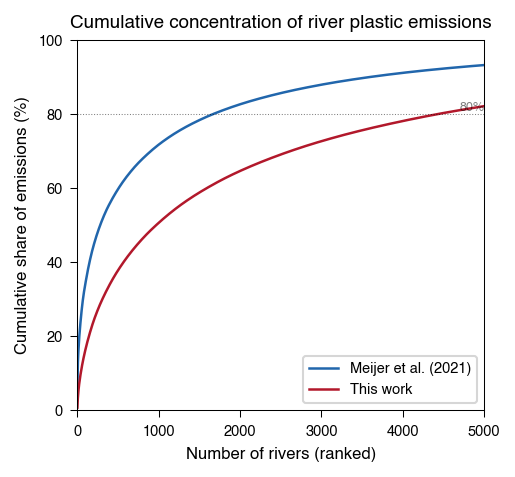

In [5]:
def cumulative_concentration(E, max_rivers=5000):
    sorted_e = np.sort(E)[::-1]
    total = sorted_e.sum()
    cumfrac = sorted_e.cumsum() / total
    n = min(max_rivers, len(E))
    return np.arange(1, n + 1), cumfrac[:n]

x_m, y_m = cumulative_concentration(E_meijer_orig)
x_u, y_u = cumulative_concentration(E_final)

fig, ax = plt.subplots(figsize=(3.5, 3.2))

ax.plot(x_m, y_m * 100, color=MEEKER_BLUE, lw=1.2, label='Meijer et al. (2021)')
ax.plot(x_u, y_u * 100, color=UPDATED_RED, lw=1.2, label='This work')

ax.axhline(80, color='k', ls=':', lw=0.5, alpha=0.5)
ax.text(4700, 81, '80%', fontsize=6, color='k', alpha=0.5)

ax.set_xlabel('Number of rivers (ranked)')
ax.set_ylabel('Cumulative share of emissions (%)')
ax.set_xlim(0, 5000)
ax.set_ylim(0, 100)
ax.legend(loc='lower right')
ax.set_title('Cumulative concentration of river plastic emissions')

fig.savefig(FIG / 'fig3_cumulative_concentration.png')
fig.savefig(FIG / 'fig3_cumulative_concentration.pdf')
plt.show()

## Figure 4: Bootstrap uncertainty

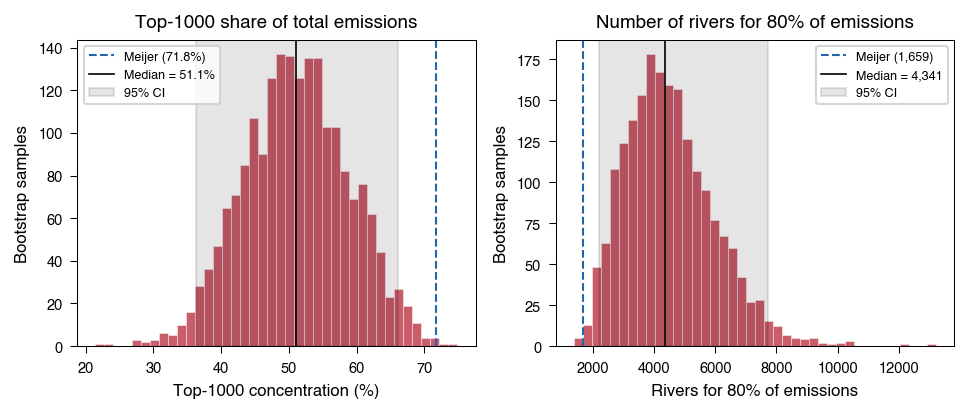

In [6]:
np.random.seed(42)
n_boot = 2000

top1000_pcts = []
n80s = []

for i in range(n_boot):
    idx_b = np.random.choice(len(log_obs), len(log_obs), replace=True)
    A_b = np.column_stack([np.ones(len(idx_b)), log_pred[idx_b], nl_dev_obs[idx_b]])
    coefs_b, _, _, _ = lstsq(A_b, log_obs[idx_b], rcond=None)
    
    cal_b = 10 ** (coefs_b[0] + coefs_b[1] * log_E + coefs_b[2] * nl_dev)
    total_b = cal_b.sum()
    top1k = np.sort(cal_b)[::-1][:1000].sum()
    top1000_pcts.append(top1k / total_b * 100)
    
    cs_b = np.sort(cal_b)[::-1].cumsum()
    n80s.append((cs_b < 0.80 * total_b).sum() + 1)

top1000_pcts = np.array(top1000_pcts)
n80s = np.array(n80s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8))

ax1.hist(top1000_pcts, bins=40, color=UPDATED_RED, alpha=0.7, edgecolor='white', linewidth=0.3)
ax1.axvline(71.8, color=MEEKER_BLUE, ls='--', lw=1, label='Meijer (71.8%)')
ax1.axvline(np.median(top1000_pcts), color='k', ls='-', lw=0.8,
            label=f'Median = {np.median(top1000_pcts):.1f}%')
ci_lo, ci_hi = np.percentile(top1000_pcts, [2.5, 97.5])
ax1.axvspan(ci_lo, ci_hi, alpha=0.1, color='k', label='95% CI')
ax1.set_xlabel('Top-1000 concentration (%)')
ax1.set_ylabel('Bootstrap samples')
ax1.set_title('Top-1000 share of total emissions')
ax1.legend(fontsize=6, loc='upper left')

ax2.hist(n80s, bins=40, color=UPDATED_RED, alpha=0.7, edgecolor='white', linewidth=0.3)
ax2.axvline(1659, color=MEEKER_BLUE, ls='--', lw=1, label='Meijer (1,659)')
ax2.axvline(np.median(n80s), color='k', ls='-', lw=0.8,
            label=f'Median = {np.median(n80s):,.0f}')
ci_lo2, ci_hi2 = np.percentile(n80s, [2.5, 97.5])
ax2.axvspan(ci_lo2, ci_hi2, alpha=0.1, color='k', label='95% CI')
ax2.set_xlabel('Rivers for 80% of emissions')
ax2.set_ylabel('Bootstrap samples')
ax2.set_title('Number of rivers for 80% of emissions')
ax2.legend(fontsize=6, loc='upper right')

fig.tight_layout()
fig.savefig(FIG / 'fig4_bootstrap_uncertainty.png')
fig.savefig(FIG / 'fig4_bootstrap_uncertainty.pdf')
plt.show()

## Figure 5: Top-20 ranking comparison

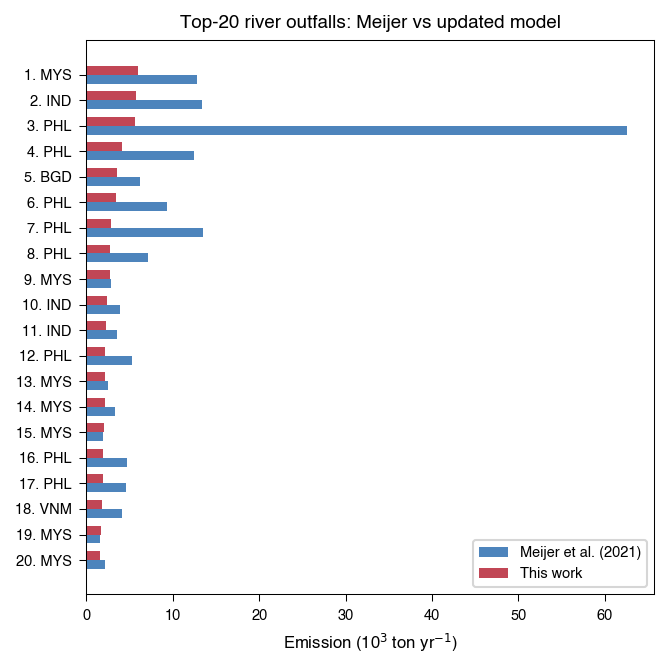

In [7]:
top20 = df.nlargest(20, 'E_final')[['country_iso', 'lat', 'lon', 'meijer_ton_yr', 'E_final']].copy()
top20['rank'] = range(1, 21)
top20['label'] = top20['rank'].astype(str) + '. ' + top20['country_iso']

fig, ax = plt.subplots(figsize=(4.5, 4.5))

y_pos = np.arange(len(top20))
bar_h = 0.35

ax.barh(y_pos + bar_h/2, top20['meijer_ton_yr'].values / 1000, bar_h,
        color=MEEKER_BLUE, alpha=0.8, label='Meijer et al. (2021)')
ax.barh(y_pos - bar_h/2, top20['E_final'].values / 1000, bar_h,
        color=UPDATED_RED, alpha=0.8, label='This work')

ax.set_yticks(y_pos)
ax.set_yticklabels(top20['label'].values)
ax.invert_yaxis()
ax.set_xlabel('Emission (10$^3$ ton yr$^{-1}$)')
ax.set_title('Top-20 river outfalls: Meijer vs updated model')
ax.legend(loc='lower right')

fig.tight_layout()
fig.savefig(FIG / 'fig5_top20_comparison.png')
fig.savefig(FIG / 'fig5_top20_comparison.pdf')
plt.show()

## Figure 6 (supplementary): Nightlight deviation effect

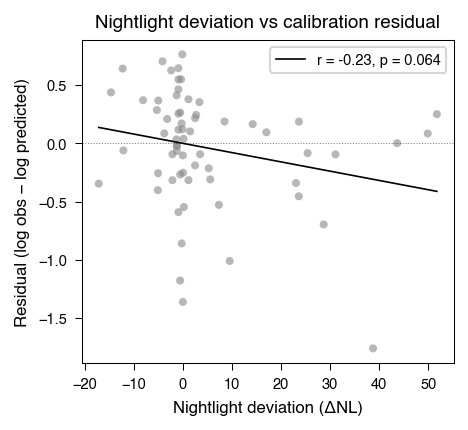

In [8]:
residuals = log_obs - (coefs[0] + coefs[1] * log_pred)

fig, ax = plt.subplots(figsize=(3.2, 2.8))

ax.scatter(nl_dev_obs, residuals, s=15, alpha=0.6, c=GRAY, edgecolors='none')

s_nl, ic_nl, r_nl, p_nl, _ = stats.linregress(nl_dev_obs, residuals)
x_nl = np.linspace(nl_dev_obs.min(), nl_dev_obs.max(), 100)
ax.plot(x_nl, ic_nl + s_nl * x_nl, 'k-', lw=0.8,
        label=f'r = {r_nl:.2f}, p = {p_nl:.3f}')

ax.axhline(0, color='k', ls=':', lw=0.5, alpha=0.5)
ax.set_xlabel('Nightlight deviation (ΔNL)')
ax.set_ylabel('Residual (log obs − log predicted)')
ax.set_title('Nightlight deviation vs calibration residual')
ax.legend()

fig.savefig(FIG / 'fig6_nightlight_residual.png')
fig.savefig(FIG / 'fig6_nightlight_residual.pdf')
plt.show()

## Figure 7 (supplementary): Japan sensitivity

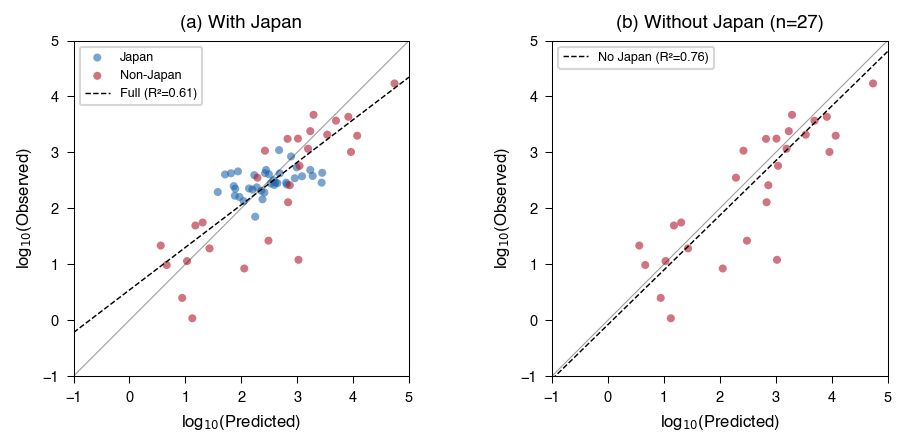

In [9]:
log_obs_nj = log_obs[~is_japan]
log_pred_nj = log_pred[~is_japan]
nl_dev_nj = nl_dev_obs[~is_japan]

A_nj = np.column_stack([np.ones(len(log_obs_nj)), log_pred_nj, nl_dev_nj])
coefs_nj, _, _, _ = lstsq(A_nj, log_obs_nj, rcond=None)
log_fitted_nj = A_nj @ coefs_nj
r2_nj = 1 - np.sum((log_obs_nj - log_fitted_nj)**2) / np.sum((log_obs_nj - log_obs_nj.mean())**2)

E_final_nj = np.zeros(len(df))
E_final_nj[mask] = 10 ** (coefs_nj[0] + coefs_nj[1] * log_E + coefs_nj[2] * nl_dev)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 3))

# Panel a: with Japan
ax1.scatter(log_pred[is_japan], log_obs[is_japan],
            s=15, alpha=0.6, c=MEEKER_BLUE, edgecolors='none', label='Japan')
ax1.scatter(log_pred[~is_japan], log_obs[~is_japan],
            s=15, alpha=0.6, c=UPDATED_RED, edgecolors='none', label='Non-Japan')
ax1.plot([-1, 5], [-1, 5], 'k-', lw=0.5, alpha=0.4)
x_l = np.linspace(-1, 5, 100)
ax1.plot(x_l, coefs[0] + coefs[1]*x_l, 'k--', lw=0.7,
         label=f'Full (R²={r2:.2f})')
ax1.set_xlim(-1, 5); ax1.set_ylim(-1, 5)
ax1.set_xlabel('log$_{10}$(Predicted)')
ax1.set_ylabel('log$_{10}$(Observed)')
ax1.set_title('(a) With Japan')
ax1.legend(fontsize=6)
ax1.set_aspect('equal')

# Panel b: without Japan
ax2.scatter(log_pred_nj, log_obs_nj, s=15, alpha=0.6, c=UPDATED_RED, edgecolors='none')
ax2.plot([-1, 5], [-1, 5], 'k-', lw=0.5, alpha=0.4)
ax2.plot(x_l, coefs_nj[0] + coefs_nj[1]*x_l, 'k--', lw=0.7,
         label=f'No Japan (R²={r2_nj:.2f})')
ax2.set_xlim(-1, 5); ax2.set_ylim(-1, 5)
ax2.set_xlabel('log$_{10}$(Predicted)')
ax2.set_ylabel('log$_{10}$(Observed)')
ax2.set_title(f'(b) Without Japan (n={(~is_japan).sum()})')
ax2.legend(fontsize=6)
ax2.set_aspect('equal')

fig.tight_layout()
fig.savefig(FIG / 'fig7_japan_sensitivity.png')
fig.savefig(FIG / 'fig7_japan_sensitivity.pdf')
plt.show()

## Figure 8 (key): Japan leverage analysis

Two panels showing how Japanese calibration rivers drive the overestimation signal:
- **(a) Leave-one-country-out slopes**: re-fit calibration dropping each country, showing Japan's outsized influence
- **(b) Jackknife leverage**: how much each observation shifts the regression slope

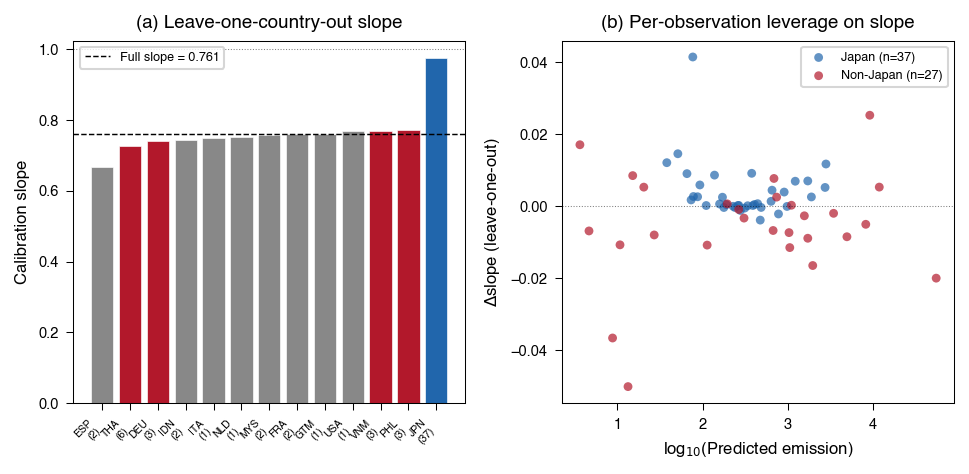

Full model slope: 0.761
LOCO without JPN: slope=0.977, R2=0.756 (n=27)
Japan points pull slope by: -0.215
Mean |delta_slope| Japan: 0.0045
Mean |delta_slope| non-Japan: 0.0107
Ratio: 0.4x


In [10]:
from collections import Counter

# (a) Leave-one-country-out regression
countries = obs_country.copy()
unique_countries = sorted(set(countries))

loco_slopes = {}
loco_r2 = {}
loco_n = {}
country_counts = Counter(countries)

for c in unique_countries:
    keep = countries != c
    n_c = keep.sum()
    if n_c < 5:
        continue
    A_loco = np.column_stack([np.ones(n_c), log_pred[keep], nl_dev_obs[keep]])
    c_loco, _, _, _ = lstsq(A_loco, log_obs[keep], rcond=None)
    fitted_loco = A_loco @ c_loco
    r2_loco = 1 - np.sum((log_obs[keep] - fitted_loco)**2) / np.sum((log_obs[keep] - log_obs[keep].mean())**2)
    loco_slopes[c] = c_loco[1]
    loco_r2[c] = r2_loco
    loco_n[c] = n_c

# (b) Jackknife slope influence per observation
n_obs = len(log_obs)
A_full = np.column_stack([np.ones(n_obs), log_pred, nl_dev_obs])
coefs_full, _, _, _ = lstsq(A_full, log_obs, rcond=None)
slope_full = coefs_full[1]

jack_slope_deltas = np.zeros(n_obs)
for i in range(n_obs):
    mask_j = np.ones(n_obs, dtype=bool)
    mask_j[i] = False
    A_j = np.column_stack([np.ones(n_obs - 1), log_pred[mask_j], nl_dev_obs[mask_j]])
    c_j, _, _, _ = lstsq(A_j, log_obs[mask_j], rcond=None)
    jack_slope_deltas[i] = c_j[1] - slope_full

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 3.2))

# Panel (a): LOCO slopes
sorted_countries = sorted(loco_slopes.keys(), key=lambda c: loco_slopes[c])
x_pos = np.arange(len(sorted_countries))
colors = [MEEKER_BLUE if c == 'JPN' else (UPDATED_RED if country_counts[c] >= 3 else GRAY) for c in sorted_countries]

ax1.bar(x_pos, [loco_slopes[c] for c in sorted_countries], color=colors, edgecolor='white', linewidth=0.3)
ax1.axhline(slope_full, color='k', ls='--', lw=0.7, label=f'Full slope = {slope_full:.3f}')
ax1.axhline(1.0, color='k', ls=':', lw=0.5, alpha=0.5)
ax1.set_xticks(x_pos)
tick_labels = [c + '\n(' + str(country_counts[c]) + ')' for c in sorted_countries]
ax1.set_xticklabels(tick_labels, fontsize=5, rotation=45, ha='right')
ax1.set_ylabel('Calibration slope')
ax1.set_title('(a) Leave-one-country-out slope')
ax1.legend(fontsize=6)

# Panel (b): Jackknife leverage
ax2.scatter(log_pred[is_japan], jack_slope_deltas[is_japan],
            s=18, alpha=0.7, c=MEEKER_BLUE, edgecolors='none', label=f'Japan (n={is_japan.sum()})')
ax2.scatter(log_pred[~is_japan], jack_slope_deltas[~is_japan],
            s=18, alpha=0.7, c=UPDATED_RED, edgecolors='none', label=f'Non-Japan (n={(~is_japan).sum()})')
ax2.axhline(0, color='k', ls=':', lw=0.5, alpha=0.5)
ax2.set_xlabel('log$_{10}$(Predicted emission)')
ax2.set_ylabel('$\\Delta$slope (leave-one-out)')
ax2.set_title('(b) Per-observation leverage on slope')
ax2.legend(fontsize=6)

fig.tight_layout()
fig.savefig(FIG / 'fig8_japan_leverage.png')
fig.savefig(FIG / 'fig8_japan_leverage.pdf')
plt.show()

print(f'Full model slope: {slope_full:.3f}')
jpn_slope = loco_slopes['JPN']
jpn_r2 = loco_r2['JPN']
jpn_n = loco_n['JPN']
print(f'LOCO without JPN: slope={jpn_slope:.3f}, R2={jpn_r2:.3f} (n={jpn_n})')
print(f'Japan points pull slope by: {slope_full - jpn_slope:.3f}')
print(f'Mean |delta_slope| Japan: {np.abs(jack_slope_deltas[is_japan]).mean():.4f}')
print(f'Mean |delta_slope| non-Japan: {np.abs(jack_slope_deltas[~is_japan]).mean():.4f}')
ratio_jp = np.abs(jack_slope_deltas[is_japan]).mean() / np.abs(jack_slope_deltas[~is_japan]).mean()
print(f'Ratio: {ratio_jp:.1f}x')

## Summary of saved figures

In [11]:
import os
for f in sorted(FIG.glob('fig*')):
    size_kb = os.path.getsize(f) / 1024
    print(f'{f.name:45s} {size_kb:6.0f} KB')

fig1_calibration_scatter.pdf                      22 KB
fig1_calibration_scatter.png                      88 KB
fig2_global_ratio_map.pdf                        647 KB
fig2_global_ratio_map.png                        197 KB
fig3_cumulative_concentration.pdf                 16 KB
fig3_cumulative_concentration.png                 85 KB
fig4_bootstrap_uncertainty.pdf                    20 KB
fig4_bootstrap_uncertainty.png                    90 KB
fig4_global_ratio_map.png                        569 KB
fig5_capture_rate_improvement.png                200 KB
fig5_top20_comparison.pdf                         22 KB
fig5_top20_comparison.png                         73 KB
fig6_nightlight_residual.pdf                      17 KB
fig6_nightlight_residual.png                      67 KB
fig6_top20_comparison.png                        212 KB
fig7_japan_sensitivity.pdf                        23 KB
fig7_japan_sensitivity.png                       101 KB
fig8_japan_leverage.pdf                         